In [3]:
import shutil
import os

# Define the specific file and folders
source_file = r'/kaggle/input/acc-sample-50-01/config.py'
destination_folder = r'/kaggle/working/'

# Create destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# Define destination path
destination_path = os.path.join(destination_folder, os.path.basename(source_file))

# Copy the file
shutil.copy2(source_file, destination_path)

print(f"Copied {source_file} to {destination_path}")

Copied /kaggle/input/acc-sample-50-01/config.py to /kaggle/working/config.py


In [4]:
import os

config_file_path = 'config.py'
new_image_size = (224, 224)
new_clip_length = 32
new_batch_size = 8# A safe starting point for ViT
new_lr = 0.0001
new_patience = 15

print("--- Modifying config.py for the Vision Transformer (ViT) experiment ---")

if not os.path.exists(config_file_path):
    print(f"FATAL: The file '{config_file_path}' was not found.")
else:
    with open(config_file_path, 'r') as f:
        lines = f.readlines()

    updates = {'IMAGE_SIZE': False, 'CLIP_LENGTH': False, 'BATCH_SIZE': False}

    for i, line in enumerate(lines):
        if line.strip().startswith('IMAGE_SIZE'):
            lines[i] = f'IMAGE_SIZE = {new_image_size}   # H, W for the model\n'
            updates['IMAGE_SIZE'] = True
        elif line.strip().startswith('CLIP_LENGTH'):
            lines[i] = f'CLIP_LENGTH = {new_clip_length}          # Frames per clip\n'
            updates['CLIP_LENGTH'] = True
        elif line.strip().startswith('BATCH_SIZE'):
            lines[i] = f'BATCH_SIZE = {new_batch_size}\n'
            updates['BATCH_SIZE'] = True
        elif line.strip().startswith('LEARNING_RATE'):
            lines[i] = f'LEARNING_RATE = {new_lr}\n'
            updates['LEARNING_RATE'] = True
        elif line.strip().startswith('PATIENCE'):
            lines[i] = f'PATIENCE = {new_patience}\n'
            updates['PATIENCE'] = True

    if all(updates.values()):
        with open(config_file_path, 'w') as f:
            f.writelines(lines)
        print("✓ Successfully updated 'config.py'.")
    else:
        print("Warning: Could not find all required settings.")

print("\n--- Verifying final content of config.py ---")
with open(config_file_path, 'r') as f:
    print(f.read())

--- Modifying config.py for the Vision Transformer (ViT) experiment ---
✓ Successfully updated 'config.py'.

--- Verifying final content of config.py ---
# config.py

# --- Kaggle Directory Paths ---
VIDEO_INPUT_DIR = "/kaggle/input/acc-sample-50/"
OUTPUT_DIR = "/kaggle/working/output/"

# --- Stage 1: Tracking Output ---
TRACKING_OUTPUT_DIR = f"{OUTPUT_DIR}/tracking_data/"

# --- Stage 5 & 6: Model Paths ---
# Use YOLOv10 Medium model
YOLO_MODEL_PATH = 'yolov10m.pt' 
# The final trained model will be saved here
SAVED_MODEL_PATH = f"{OUTPUT_DIR}/3d_cnn_accident_detector.pth"

# --- Data Processing Parameters ---
CLIP_LENGTH = 32          # Frames per clip
IMAGE_SIZE = (224, 224)   # H, W for the model

# --- Training Parameters ---
# Use a smaller batch size for 3D-CNNs due to higher memory usage
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 0.0001
PATIENCE = 15



In [5]:
!pip install ultralytics supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 101.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/2

In [7]:
!pip install -q timm

In [4]:
# step_4_prepare_multimodal_dataset.py (Version with Rich Features, Severity Labels, and Parser Fix)
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from itertools import combinations
import shutil
# Assuming 'config' is a file you have with your settings
# import config 

# --- A placeholder for config if you don't have a separate file ---
class Config:
    VIDEO_INPUT_DIR = "/kaggle/input/acc-dataset/total/" # <-- IMPORTANT: Update this path
    TRACKING_OUTPUT_DIR = "/kaggle/input/acc-sample-50-01/output/tracking_data/" # <-- IMPORTANT: Update this path
    OUTPUT_DIR = "/kaggle/working/"
    CLIP_LENGTH = 32
    IMAGE_SIZE = (224, 224)

config = Config()
# ----------------------------------------------------

# --- Configuration for this Step ---
MASTER_LABELS_PATH = "/kaggle/input/acc-ground-truth/acc-master_ground_truth_events.csv" # <-- IMPORTANT: Update this path
PREPARED_DATA_DIR = f"{config.OUTPUT_DIR}/prepared_dataset/"

NUM_EASY_NEGATIVE_SAMPLES = 4
NUM_HARD_NEGATIVE_SAMPLES = 5

# --- SEVERITY MAPPING: Map string labels to integers ---
SEVERITY_MAP = {
    'low': 1,
    'medium': 2,
    'high': 3
}
# ------------------------------------------------------

def extract_clip_frames(video_path, start_frame, clip_length, output_dir, image_size):
    output_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened(): return False
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if start_frame < 0 or start_frame + clip_length > total_frames:
        cap.release(); return False
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    for i in range(clip_length):
        ret, frame = cap.read()
        if not ret: break
        frame_resized = cv2.resize(frame, image_size)
        cv2.imwrite(str(output_dir / f"{i:03d}.jpg"), frame_resized)
    cap.release()
    return True

def main():
    print("--- Step 4: Preparing Dataset with RICH Features & SEVERITY ---")
    if not Path(MASTER_LABELS_PATH).exists():
        print(f"FATAL: Master labels file not found at {MASTER_LABELS_PATH}"); return

    # --- FIX: Use the 'python' engine to avoid the TypeError ---
    try:
        labels_df = pd.read_csv(MASTER_LABELS_PATH, engine='python')
    except Exception as e:
        print(f"FATAL: Could not read the master labels CSV. Error: {e}")
        return
    # -------------------------------------------------------------

    all_clip_manifest_data = []
    prepared_clips_dir = Path(PREPARED_DATA_DIR) / "clips"
    if prepared_clips_dir.exists():
        print("Clearing existing prepared data directory...")
        shutil.rmtree(prepared_clips_dir)
    prepared_clips_dir.mkdir(parents=True, exist_ok=True)

    for _, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc="Processing Labeled Videos"):
        clip_name = row['clip_name']
        event_start, event_end = row['event_start_frame'], row['event_end_frame']
        
        severity_str = row['severity']
        positive_label = SEVERITY_MAP.get(severity_str, 0) 
        if positive_label == 0:
            print(f"Warning: Clip '{clip_name}' has an unknown severity '{severity_str}'. Skipping.")
            continue

        video_path = Path(config.VIDEO_INPUT_DIR) / f"{clip_name}.mp4"
        track_path = Path(config.TRACKING_OUTPUT_DIR) / f"{clip_name}_tracks.csv"
        if not video_path.exists() or not track_path.exists(): continue

        try:
            track_df = pd.read_csv(track_path)
        except Exception:
            print(f"Warning: Could not read tracking file for {clip_name}. Skipping.")
            continue

        if track_df.empty: continue

        # --- RICH FEATURE CALCULATION (No changes here) ---
        track_df = track_df.sort_values(by=['track_id', 'frame'])
        track_df['x_center'] = (track_df['x_min'] + track_df['x_max']) / 2
        track_df['y_center'] = (track_df['y_min'] + track_df['y_max']) / 2
        track_df[['dx', 'dy']] = track_df.groupby('track_id')[['x_center', 'y_center']].diff().fillna(0)
        track_df['velocity'] = np.sqrt(track_df['dx']**2 + track_df['dy']**2)
        track_df['deceleration'] = -track_df.groupby('track_id')['velocity'].diff().fillna(0)
        v_prev = track_df.groupby('track_id')[['dx', 'dy']].shift(1).fillna(0).to_numpy()
        v_curr = track_df[['dx', 'dy']].to_numpy()
        dot_product = np.sum(v_prev * v_curr, axis=1)
        norm_v_prev = np.linalg.norm(v_prev, axis=1); norm_v_curr = np.linalg.norm(v_curr, axis=1)
        denominator = norm_v_prev * norm_v_curr
        cosine_angle = np.divide(dot_product, denominator, out=np.ones_like(dot_product), where=denominator!=0)
        track_df['direction_change'] = np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))
        iou_data = []
        for frame_num, frame_df in track_df.groupby('frame'):
            max_iou = 0
            if len(frame_df) > 1:
                for i, j in combinations(frame_df.index, 2):
                    box1 = frame_df.loc[i, ['x_min', 'y_min', 'x_max', 'y_max']].values
                    box2 = frame_df.loc[j, ['x_min', 'y_min', 'x_max', 'y_max']].values
                    inter_x1, inter_y1 = max(box1[0], box2[0]), max(box1[1], box2[1])
                    inter_x2, inter_y2 = min(box1[2], box2[2]), min(box1[3], box2[3])
                    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
                    if inter_area > 0:
                        box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1]); box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
                        union_area = box1_area + box2_area - inter_area
                        max_iou = max(max_iou, inter_area / union_area if union_area > 0 else 0)
            iou_data.append({'frame': frame_num, 'max_iou': max_iou})
        track_df = pd.merge(track_df, pd.DataFrame(iou_data), on='frame', how='left')
        frame_features = track_df.groupby('frame').agg(
            max_deceleration=('deceleration', 'max'),
            max_iou=('max_iou', 'max'),
            max_direction_change=('direction_change', 'max')
        ).reset_index().set_index('frame')
        # --- END: RICH FEATURE CALCULATION ---

        def slice_and_save(start_f, label, clip_idx):
            clip_output_dir = prepared_clips_dir / f"label_{label}" / f"{clip_name}_{clip_idx}"
            if not extract_clip_frames(video_path, start_f, config.CLIP_LENGTH, clip_output_dir, config.IMAGE_SIZE): return
            end_f = start_f + config.CLIP_LENGTH
            # Ensure start_f is in the index before trying to slice
            if start_f not in frame_features.index: return
            clip_feature_df = frame_features.loc[start_f:end_f-1].copy()
            if len(clip_feature_df) < config.CLIP_LENGTH:
                 padding = pd.DataFrame(0, index=range(config.CLIP_LENGTH - len(clip_feature_df)), columns=clip_feature_df.columns)
                 clip_feature_df = pd.concat([clip_feature_df, padding])
            feature_path = clip_output_dir / "features.csv"
            clip_feature_df.to_csv(feature_path, index=False)
            all_clip_manifest_data.append({"clip_path": str(clip_output_dir), "feature_path": str(feature_path), "label": label})

        step = config.CLIP_LENGTH // 4
        for start_frame in range(event_start - step, event_end - config.CLIP_LENGTH + step, step):
            slice_and_save(start_frame, positive_label, f"crash_{start_frame}")
        
        safety_margin = config.CLIP_LENGTH * 2 
        max_easy_neg_start = event_start - safety_margin
        if max_easy_neg_start > 0:
            easy_neg_frames = np.linspace(0, max_easy_neg_start, NUM_EASY_NEGATIVE_SAMPLES, dtype=int)
            for i, start_frame in enumerate(easy_neg_frames): slice_and_save(start_frame, 0, f"easy_neg_{i}")

        for i in range(NUM_HARD_NEGATIVE_SAMPLES):
            start_frame = event_start - config.CLIP_LENGTH - (i * step)
            if start_frame >= 0: slice_and_save(start_frame, 0, f"hard_neg_{i}")
    
    if not all_clip_manifest_data:
        print("\n--- WARNING: No clips were generated. Check your paths and input files. ---")
        return

    manifest_df = pd.DataFrame(all_clip_manifest_data)
    manifest_path = Path(PREPARED_DATA_DIR) / "training_manifest.csv"
    manifest_df.to_csv(manifest_path, index=False)
    
    print(f"\n--- Data Preparation Complete ---"); print(f"Generated {len(manifest_df)} total clips.")
    print("Label distribution:")
    print(manifest_df['label'].value_counts())
    print("\nMapping: 0=no_crash, 1=low, 2=medium, 3=high")
    print(f"Final training manifest saved to: {manifest_path}")

if __name__ == '__main__':
    main()

--- Step 4: Preparing Dataset with RICH Features & SEVERITY ---
Clearing existing prepared data directory...


Processing Labeled Videos: 100%|██████████| 607/607 [1:29:51<00:00,  8.88s/it]   


--- Data Preparation Complete ---
Generated 5015 total clips.
Label distribution:
label
0    2192
2    1522
3    1010
1     291
Name: count, dtype: int64

Mapping: 0=no_crash, 1=low, 2=medium, 3=high
Final training manifest saved to: /kaggle/working/prepared_dataset/training_manifest.csv


In [10]:
import torch

# Clear GPU cache
torch.cuda.empty_cache()

In [ ]:
### `step_5_train_vit_model.py` (Fully Resumable)


# step_5_train_vit_model.py (FINAL Version with Full Resume Capability)
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.cuda.amp import autocast, GradScaler

# --- Configuration ---
class Config:
    OUTPUT_DIR = "/kaggle/working/"
    BATCH_SIZE = 16
    ACCUMULATION_STEPS = 2
    LEARNING_RATE = 1e-4
    EPOCHS = 25
    PATIENCE = 5
    BEST_MODEL_PATH = f"{OUTPUT_DIR}/vit_severity_model_best.pth"
    # --- NEW: Path for the resume checkpoint ---
    CHECKPOINT_PATH = f"{OUTPUT_DIR}/checkpoint.pth"

config = Config()
# ---------------------------------

# --- Setup ---
PREPARED_DATA_DIR = f"{config.OUTPUT_DIR}/prepared_dataset/"
MANIFEST_PATH = os.path.join(PREPARED_DATA_DIR, "training_manifest.csv")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(f"✓ Using device: {device}")
    print(f"✓ {torch.cuda.device_count()} GPUs available!")

# --- Dataset and Model Classes (No changes here) ---
class MultimodalDataset(Dataset):
    def __init__(self, manifest_df, transform=None):
        self.manifest_df = manifest_df
        self.transform = transform if transform else transforms.ToTensor()
    def __len__(self): return len(self.manifest_df)
    def __getitem__(self, idx):
        row = self.manifest_df.iloc[idx]
        frame_files = sorted(glob.glob(os.path.join(row['clip_path'], "*.jpg")))
        frames = [Image.open(f).convert("RGB") for f in frame_files]
        if not frames: return None, None
        video_tensor = torch.stack([self.transform(frame) for frame in frames])
        feature_df = pd.read_csv(row['feature_path'])
        features = feature_df[['max_deceleration', 'max_iou', 'max_direction_change']].values.astype(np.float32)
        feature_tensor = torch.from_numpy(features)
        label = torch.tensor(row['label'], dtype=torch.long)
        return (video_tensor, feature_tensor), label

class VisionTransformerAccidentDetector(nn.Module):
    def __init__(self, num_features, num_classes, hidden_size=256, dropout=0.5):
        super(VisionTransformerAccidentDetector, self).__init__()
        self.base_model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0, global_pool='avg')
        num_video_features = self.base_model.num_features
        self.video_gru = nn.GRU(input_size=num_video_features, hidden_size=hidden_size, batch_first=True)
        self.feature_gru = nn.GRU(input_size=num_features, hidden_size=hidden_size // 4, batch_first=True)
        self.classifier = nn.Sequential(nn.Linear(hidden_size + hidden_size // 4, 512), nn.ReLU(), nn.Dropout(dropout), nn.Linear(512, num_classes))
    def forward(self, video_input, feature_input):
        batch_size, clip_len, C, H, W = video_input.shape
        video_input_reshaped = video_input.view(batch_size * clip_len, C, H, W)
        video_features = self.base_model(video_input_reshaped)
        video_features_seq = video_features.view(batch_size, clip_len, -1)
        _, video_hidden = self.video_gru(video_features_seq)
        _, feature_hidden = self.feature_gru(feature_input)
        video_hidden = video_hidden.squeeze(0); feature_hidden = feature_hidden.squeeze(0)
        fused = torch.cat((video_hidden, feature_hidden), dim=1)
        return self.classifier(fused)

def collate_fn(batch):
    batch = [item for item in batch if item[0] is not None]
    if not batch: return None, None
    return torch.utils.data.dataloader.default_collate(batch)

# --- Main Training Workflow ---
def main():
    print("--- Step 5: Training with Full Resume Capability ---")
    manifest_df = pd.read_csv(MANIFEST_PATH)
    train_df, val_df = train_test_split(manifest_df, test_size=0.2, random_state=42, stratify=manifest_df['label'])
    
    transform = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.ColorJitter(brightness=0.3, contrast=0.3), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    
    train_dataset = MultimodalDataset(train_df, transform)
    val_dataset = MultimodalDataset(val_df, transform)
    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)
    
    class_weights = torch.tensor(compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label']), dtype=torch.float32).to(device)
    print(f"Using class weights: {class_weights}")
    
    model = VisionTransformerAccidentDetector(num_features=3, num_classes=4)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs!")
        model = nn.DataParallel(model)
    model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
    scaler = GradScaler()
    
    # --- NEW: Initialize variables for resuming ---
    start_epoch = 0
    best_val_loss = float('inf')
    patience_counter = 0

    # --- NEW: Load checkpoint if it exists ---
    if os.path.exists(config.CHECKPOINT_PATH):
        print("--- Checkpoint found! Resuming training. ---")
        checkpoint = torch.load(config.CHECKPOINT_PATH)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        patience_counter = checkpoint.get('patience_counter', 0) # Use .get for backward compatibility
        print(f"Resuming from Epoch {start_epoch}")

    # --- NEW: Modified training loop to start from the correct epoch ---
    for epoch in range(start_epoch, config.EPOCHS):
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()
        
        for i, ((video, features), labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS} [Train]")):
            if video is None: continue
            video, features, labels = video.to(device), features.to(device), labels.to(device)
            
            with autocast():
                outputs = model(video, features)
                loss = criterion(outputs, labels)
                loss = loss / config.ACCUMULATION_STEPS

            scaler.scale(loss).backward()
            
            if (i + 1) % config.ACCUMULATION_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            train_loss += loss.item() * config.ACCUMULATION_STEPS

        # Evaluation loop
        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for (video, features), labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS} [Val]"):
                if video is None: continue
                video, features, labels = video.to(device), features.to(device), labels.to(device)
                with autocast():
                    outputs = model(video, features)
                    loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)

        avg_train_loss = train_loss/len(train_loader); avg_val_loss = val_loss/len(val_loader)
        val_accuracy = val_corrects.double()/len(val_dataset)
        
        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}")
        
        if avg_val_loss < best_val_loss:
            print(f"Validation loss improved. Saving best model...");
            torch.save(model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(), config.BEST_MODEL_PATH)
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"Validation loss did not improve. Patience: {patience_counter}/{config.PATIENCE}")

        # --- NEW: Save a full checkpoint after every epoch ---
        print("Saving checkpoint...")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter,
        }, config.CHECKPOINT_PATH)

        if patience_counter >= config.PATIENCE:
            print("Early stopping triggered."); break

    print(f"\n--- Training Complete ---"); print(f"Best model saved to: {config.BEST_MODEL_PATH}")

if __name__ == "__main__":
    main()

✓ Using device: cuda
✓ 2 GPUs available!
--- Step 5: Training with Full Resume Capability ---
Using class weights: tensor([0.5722, 4.3047, 0.8235, 1.2413], device='cuda:0')


/tmp/ipykernel_37/1081840110.py:110: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Using 2 GPUs!


Epoch 1/25 [Train]:   0%|          | 0/251 [00:00<?, ?it/s]/tmp/ipykernel_37/1081840110.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/25 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_37/1081840110.py:160: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/25 [Val]: 100%|██████████| 63/63 [01:09<00:00,  1.10s/it]


Epoch 1: Train Loss: 1.2994, Val Loss: 1.0958, Val Acc: 0.4676
Validation loss improved. Saving best model...
Saving checkpoint...


...

Epoch 14/25 [Val]: 100%|██████████| 63/63 [01:09<00:00,  1.10s/it]


Epoch 14: Train Loss: 0.1029, Val Loss: 0.3717, Val Acc: 0.9063
Validation loss improved. Saving best model...
Saving checkpoint...


Epoch 15/25 [Val]: 100%|██████████| 63/63 [01:08<00:00,  1.09s/it]


Epoch 15: Train Loss: 0.0832, Val Loss: 0.4201, Val Acc: 0.8953
Validation loss did not improve. Patience: 1/5
Saving checkpoint...


Epoch 16/25 [Train]:   2%|▏         | 4/251 [00:05<04:57,  1.20s/it]

In [5]:
### `step_5_train_vit_model.py` (Fully Resumable)


# step_5_train_vit_model.py (FINAL Version with Full Resume Capability)
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.cuda.amp import autocast, GradScaler

# --- Configuration ---
class Config:
    OUTPUT_DIR = "/kaggle/working/"
    BATCH_SIZE = 16
    ACCUMULATION_STEPS = 2
    LEARNING_RATE = 1e-4
    EPOCHS = 25
    PATIENCE = 5
    BEST_MODEL_PATH = f"{OUTPUT_DIR}/vit_severity_model_best.pth"
    # --- NEW: Path for the resume checkpoint ---
    CHECKPOINT_PATH = f"{OUTPUT_DIR}/checkpoint.pth"

config = Config()
# ---------------------------------

# --- Setup ---
PREPARED_DATA_DIR = f"{config.OUTPUT_DIR}/prepared_dataset/"
MANIFEST_PATH = os.path.join(PREPARED_DATA_DIR, "training_manifest.csv")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(f"✓ Using device: {device}")
    print(f"✓ {torch.cuda.device_count()} GPUs available!")

# --- Dataset and Model Classes (No changes here) ---
class MultimodalDataset(Dataset):
    def __init__(self, manifest_df, transform=None):
        self.manifest_df = manifest_df
        self.transform = transform if transform else transforms.ToTensor()
    def __len__(self): return len(self.manifest_df)
    def __getitem__(self, idx):
        row = self.manifest_df.iloc[idx]
        frame_files = sorted(glob.glob(os.path.join(row['clip_path'], "*.jpg")))
        frames = [Image.open(f).convert("RGB") for f in frame_files]
        if not frames: return None, None
        video_tensor = torch.stack([self.transform(frame) for frame in frames])
        feature_df = pd.read_csv(row['feature_path'])
        features = feature_df[['max_deceleration', 'max_iou', 'max_direction_change']].values.astype(np.float32)
        feature_tensor = torch.from_numpy(features)
        label = torch.tensor(row['label'], dtype=torch.long)
        return (video_tensor, feature_tensor), label

class VisionTransformerAccidentDetector(nn.Module):
    def __init__(self, num_features, num_classes, hidden_size=256, dropout=0.5):
        super(VisionTransformerAccidentDetector, self).__init__()
        self.base_model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0, global_pool='avg')
        num_video_features = self.base_model.num_features
        self.video_gru = nn.GRU(input_size=num_video_features, hidden_size=hidden_size, batch_first=True)
        self.feature_gru = nn.GRU(input_size=num_features, hidden_size=hidden_size // 4, batch_first=True)
        self.classifier = nn.Sequential(nn.Linear(hidden_size + hidden_size // 4, 512), nn.ReLU(), nn.Dropout(dropout), nn.Linear(512, num_classes))
    def forward(self, video_input, feature_input):
        batch_size, clip_len, C, H, W = video_input.shape
        video_input_reshaped = video_input.view(batch_size * clip_len, C, H, W)
        video_features = self.base_model(video_input_reshaped)
        video_features_seq = video_features.view(batch_size, clip_len, -1)
        _, video_hidden = self.video_gru(video_features_seq)
        _, feature_hidden = self.feature_gru(feature_input)
        video_hidden = video_hidden.squeeze(0); feature_hidden = feature_hidden.squeeze(0)
        fused = torch.cat((video_hidden, feature_hidden), dim=1)
        return self.classifier(fused)

def collate_fn(batch):
    batch = [item for item in batch if item[0] is not None]
    if not batch: return None, None
    return torch.utils.data.dataloader.default_collate(batch)

# --- Main Training Workflow ---
def main():
    print("--- Step 5: Training with Full Resume Capability ---")
    manifest_df = pd.read_csv(MANIFEST_PATH)
    train_df, val_df = train_test_split(manifest_df, test_size=0.2, random_state=42, stratify=manifest_df['label'])
    
    transform = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.ColorJitter(brightness=0.3, contrast=0.3), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    
    train_dataset = MultimodalDataset(train_df, transform)
    val_dataset = MultimodalDataset(val_df, transform)
    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)
    
    class_weights = torch.tensor(compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label']), dtype=torch.float32).to(device)
    print(f"Using class weights: {class_weights}")
    
    model = VisionTransformerAccidentDetector(num_features=3, num_classes=4)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs!")
        model = nn.DataParallel(model)
    model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
    scaler = GradScaler()
    
    # --- NEW: Initialize variables for resuming ---
    start_epoch = 0
    best_val_loss = float('inf')
    patience_counter = 0

    # --- NEW: Load checkpoint if it exists ---
    if os.path.exists(config.CHECKPOINT_PATH):
        print("--- Checkpoint found! Resuming training. ---")
        checkpoint = torch.load(config.CHECKPOINT_PATH)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        patience_counter = checkpoint.get('patience_counter', 0) # Use .get for backward compatibility
        print(f"Resuming from Epoch {start_epoch}")

    # --- NEW: Modified training loop to start from the correct epoch ---
    for epoch in range(start_epoch, config.EPOCHS):
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()
        
        for i, ((video, features), labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS} [Train]")):
            if video is None: continue
            video, features, labels = video.to(device), features.to(device), labels.to(device)
            
            with autocast():
                outputs = model(video, features)
                loss = criterion(outputs, labels)
                loss = loss / config.ACCUMULATION_STEPS

            scaler.scale(loss).backward()
            
            if (i + 1) % config.ACCUMULATION_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            train_loss += loss.item() * config.ACCUMULATION_STEPS

        # Evaluation loop
        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for (video, features), labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS} [Val]"):
                if video is None: continue
                video, features, labels = video.to(device), features.to(device), labels.to(device)
                with autocast():
                    outputs = model(video, features)
                    loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)

        avg_train_loss = train_loss/len(train_loader); avg_val_loss = val_loss/len(val_loader)
        val_accuracy = val_corrects.double()/len(val_dataset)
        
        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}")
        
        if avg_val_loss < best_val_loss:
            print(f"Validation loss improved. Saving best model...");
            torch.save(model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(), config.BEST_MODEL_PATH)
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"Validation loss did not improve. Patience: {patience_counter}/{config.PATIENCE}")

        # --- NEW: Save a full checkpoint after every epoch ---
        print("Saving checkpoint...")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter,
        }, config.CHECKPOINT_PATH)

        if patience_counter >= config.PATIENCE:
            print("Early stopping triggered."); break

    print(f"\n--- Training Complete ---"); print(f"Best model saved to: {config.BEST_MODEL_PATH}")

if __name__ == "__main__":
    main()

✓ Using device: cuda
✓ 2 GPUs available!
--- Step 5: Training with Full Resume Capability ---
Using class weights: tensor([0.5722, 4.3047, 0.8235, 1.2413], device='cuda:0')


/tmp/ipykernel_37/1081840110.py:110: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Using 2 GPUs!
--- Checkpoint found! Resuming training. ---
Resuming from Epoch 19


Epoch 20/25 [Train]:   0%|          | 0/251 [00:00<?, ?it/s]/tmp/ipykernel_37/1081840110.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 20/25 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_37/1081840110.py:160: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 20/25 [Val]: 100%|██████████| 63/63 [01:14<00:00,  1.18s/it]


Epoch 20: Train Loss: 0.0563, Val Loss: 0.4175, Val Acc: 0.9073
Validation loss did not improve. Patience: 6/5
Saving checkpoint...
Early stopping triggered.

--- Training Complete ---
Best model saved to: /kaggle/working//vit_severity_model_best.pth


✓ Using device: cuda
--- Step 6: Evaluating and Visualizing Model Results ---
Loading model from /kaggle/working//vit_severity_model_best.pth
Using 2 GPUs for evaluation!


Evaluating on Validation Set: 100%|██████████| 32/32 [00:48<00:00,  1.50s/it]



--- Classification Report ---
              precision    recall  f1-score   support

    no_crash       0.91      0.88      0.90       439
         low       0.76      0.86      0.81        58
      medium       0.89      0.91      0.90       304
        high       0.89      0.91      0.90       202

    accuracy                           0.89      1003
   macro avg       0.86      0.89      0.88      1003
weighted avg       0.89      0.89      0.89      1003


--- Generating Confusion Matrix ---
✓ Confusion matrix saved to /kaggle/working//evaluation_results/

--- Generating Visual Examples (GIFs) ---


Creating GIFs: 100%|██████████| 10/10 [00:08<00:00,  1.19it/s]


✓ 10 visual examples saved as GIFs in /kaggle/working//evaluation_results/

--- Evaluation Complete ---


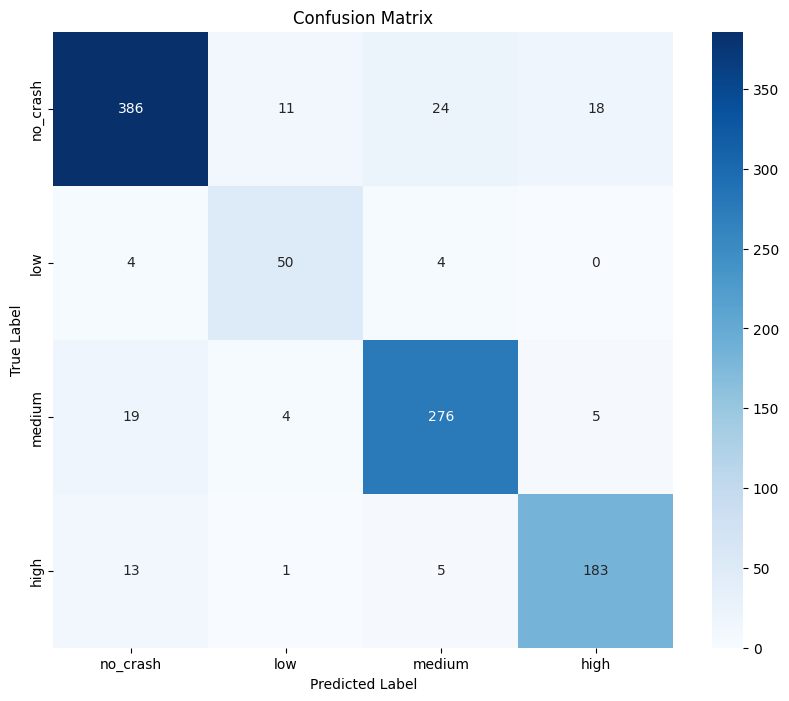

In [6]:
# step_6_evaluate_and_visualize.py
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# --- Configuration ---
class Config:
    OUTPUT_DIR = "/kaggle/working/"
    BATCH_SIZE = 32 # Can use a larger batch size for evaluation
    
config = Config()
# ----------------------------------------------------

# --- Setup Paths and Labels ---
PREPARED_DATA_DIR = f"{config.OUTPUT_DIR}/prepared_dataset/"
MANIFEST_PATH = os.path.join(PREPARED_DATA_DIR, "training_manifest.csv")
# --- IMPORTANT: Updated to use the 'best' model saved by your script ---
MODEL_PATH = f"{config.OUTPUT_DIR}/vit_severity_model_best.pth"
RESULTS_DIR = f"{config.OUTPUT_DIR}/evaluation_results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

CLASS_NAMES = ['no_crash', 'low', 'medium', 'high']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Using device: {device}")

# --- Re-define Dataset and Model classes (must be identical to training script) ---
class MultimodalDataset(Dataset):
    def __init__(self, manifest_df, transform=None):
        self.manifest_df = manifest_df
        self.transform = transform if transform else transforms.ToTensor()
    def __len__(self): return len(self.manifest_df)
    def __getitem__(self, idx):
        row = self.manifest_df.iloc[idx]
        clip_path = row['clip_path']
        frame_files = sorted(glob.glob(os.path.join(clip_path, "*.jpg")))
        frames = [Image.open(f).convert("RGB") for f in frame_files]
        if not frames: return None, None, None
        video_tensor = torch.stack([self.transform(frame) for frame in frames])
        feature_df = pd.read_csv(row['feature_path'])
        features = feature_df[['max_deceleration', 'max_iou', 'max_direction_change']].values.astype(np.float32)
        feature_tensor = torch.from_numpy(features)
        label = torch.tensor(row['label'], dtype=torch.long)
        return (video_tensor, feature_tensor), label, clip_path

class VisionTransformerAccidentDetector(nn.Module):
    def __init__(self, num_features, num_classes, hidden_size=256, dropout=0.5):
        super(VisionTransformerAccidentDetector, self).__init__()
        self.base_model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0, global_pool='avg')
        num_video_features = self.base_model.num_features
        self.video_gru = nn.GRU(input_size=num_video_features, hidden_size=hidden_size, batch_first=True)
        self.feature_gru = nn.GRU(input_size=num_features, hidden_size=hidden_size // 4, batch_first=True)
        self.classifier = nn.Sequential(nn.Linear(hidden_size + hidden_size // 4, 512), nn.ReLU(), nn.Dropout(dropout), nn.Linear(512, num_classes))
    def forward(self, video_input, feature_input):
        batch_size, clip_len, C, H, W = video_input.shape
        video_input_reshaped = video_input.view(batch_size * clip_len, C, H, W)
        video_features = self.base_model(video_input_reshaped)
        video_features_seq = video_features.view(batch_size, clip_len, -1)
        _, video_hidden = self.video_gru(video_features_seq)
        _, feature_hidden = self.feature_gru(feature_input)
        video_hidden = video_hidden.squeeze(0); feature_hidden = feature_hidden.squeeze(0)
        fused = torch.cat((video_hidden, feature_hidden), dim=1)
        return self.classifier(fused)

def collate_fn(batch):
    batch = [item for item in batch if item[0] is not None]
    if not batch: return None, None, None
    data_and_labels = [(item[0], item[1]) for item in batch]
    clip_paths = [item[2] for item in batch]
    collated_data, collated_labels = torch.utils.data.dataloader.default_collate(data_and_labels)
    return collated_data, collated_labels, clip_paths

def create_visual_result(clip_path, true_label_str, pred_label_str, output_path):
    frames = []
    frame_files = sorted(glob.glob(os.path.join(clip_path, "*.jpg")))
    is_correct = (true_label_str == pred_label_str)
    text_color = (0, 255, 0) if is_correct else (0, 0, 255)
    for f_path in frame_files:
        frame = cv2.imread(f_path)
        cv2.rectangle(frame, (5, 5), (200, 60), (0,0,0), -1)
        cv2.putText(frame, f"Actual: {true_label_str}", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, text_color, 2)
        cv2.putText(frame, f"Predicted: {pred_label_str}", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, text_color, 2)
        frames.append(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
    if frames:
        frames[0].save(output_path, save_all=True, append_images=frames[1:], duration=100, loop=0)

def main():
    print("--- Step 6: Evaluating and Visualizing Model Results ---")
    manifest_df = pd.read_csv(MANIFEST_PATH)
    _, val_df = train_test_split(manifest_df, test_size=0.2, random_state=42, stratify=manifest_df['label'])
    eval_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    val_dataset = MultimodalDataset(val_df, eval_transform)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)
    
    print(f"Loading model from {MODEL_PATH}")
    model = VisionTransformerAccidentDetector(num_features=3, num_classes=4)
    # The model was saved using nn.DataParallel, so it has a 'module.' prefix in its keys.
    # We need to load it correctly whether we are using DataParallel for evaluation or not.
    state_dict = torch.load(MODEL_PATH)
    model.load_state_dict(state_dict)
        
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for evaluation!")
        model = nn.DataParallel(model)
    model.to(device)
    model.eval()

    all_preds, all_labels, all_clip_paths = [], [], []
    with torch.no_grad():
        for (video, features), labels, clip_paths in tqdm(val_loader, desc="Evaluating on Validation Set"):
            if video is None: continue
            video, features, labels = video.to(device), features.to(device), labels.to(device)
            outputs = model(video, features)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_clip_paths.extend(clip_paths)

    print("\n--- Classification Report ---")
    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0)
    print(report)
    with open(os.path.join(RESULTS_DIR, "classification_report.txt"), "w") as f: f.write(report)

    print("\n--- Generating Confusion Matrix ---")
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.title('Confusion Matrix')
    plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"))
    print(f"✓ Confusion matrix saved to {RESULTS_DIR}")

    print("\n--- Generating Visual Examples (GIFs) ---")
    results_df = pd.DataFrame({'clip_path': all_clip_paths, 'true_label': all_labels, 'pred_label': all_preds})
    correct_samples = results_df[results_df['true_label'] == results_df['pred_label']].sample(n=min(5, len(results_df[results_df['true_label'] == results_df['pred_label']])))
    incorrect_samples = results_df[results_df['true_label'] != results_df['pred_label']].sample(n=min(5, len(results_df[results_df['true_label'] != results_df['pred_label']])))
    samples_to_visualize = pd.concat([correct_samples, incorrect_samples])
    
    for _, row in tqdm(samples_to_visualize.iterrows(), total=len(samples_to_visualize), desc="Creating GIFs"):
        clip_name = os.path.basename(row['clip_path'])
        true_str, pred_str = CLASS_NAMES[row['true_label']], CLASS_NAMES[row['pred_label']]
        status = "CORRECT" if true_str == pred_str else "INCORRECT"
        gif_filename = f"{status}_{clip_name}.gif"
        output_path = os.path.join(RESULTS_DIR, gif_filename)
        create_visual_result(row['clip_path'], true_str, pred_str, output_path)

    print(f"\n✓ {len(samples_to_visualize)} visual examples saved as GIFs in {RESULTS_DIR}")
    print("\n--- Evaluation Complete ---")

if __name__ == "__main__":
    main()

In [7]:
import shutil

# Specify the folder to be zipped
folder_to_zip = '/kaggle/working/evaluation_results'

# Specify the output ZIP file name (without extension)
output_zip = '/kaggle/working/evaluation_results'

# Create the ZIP archive
shutil.make_archive(output_zip, 'zip', folder_to_zip)

print(f"Folder '{folder_to_zip}' has been zipped as '{output_zip}.zip'")

Folder '/kaggle/working/evaluation_results' has been zipped as '/kaggle/working/evaluation_results.zip'


In [1]:
import os

# --- Define URLs and Destination Paths ---
# This is where the files will be saved in your Kaggle environment
output_directory = "/kaggle/working/"

# Dictionary of files to download { "url": "output_filename" }
files_to_download = {
    "https://github.com/ultralytics/assets/releases/download/v8.3.0/yolov10m.pt": "yolov10m.pt",
    "https://huggingface.co/timm/vit_tiny_patch16_224.augreg_in21k_ft_in1k/resolve/main/model.safetensors": "model.safetensors"
}

print(f"--- Starting Download to {output_directory} ---")

# --- Loop through the files and download them using the !wget command ---
for url, filename in files_to_download.items():
    destination_path = os.path.join(output_directory, filename)
    print(f"\nDownloading {filename}...")
    # The -O flag tells wget to save the file to a specific path and name
    !wget -q --show-progress -O {destination_path} "{url}"

print("\n--- Download Complete ---")
print("Verifying that the files exist...\n")

--- Starting Download to /kaggle/working/ ---

/kaggle/working/yol 100%[===================>]  32.08M   146MB/s    in 0.2s    

/kaggle/working/mod 100%[===================>]  21.82M   142MB/s    in 0.2s    

--- Download Complete ---
Verifying that the files exist...



In [1]:
### `step_5_train_vit_model.py` (Fully Resumable)


# step_5_train_vit_model.py (FINAL Version with Full Resume Capability)
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.cuda.amp import autocast, GradScaler

# --- Configuration ---
class Config:
    OUTPUT_DIR = "/kaggle/working/"
    BATCH_SIZE = 16
    ACCUMULATION_STEPS = 2
    LEARNING_RATE = 1e-4
    EPOCHS = 40
    PATIENCE = 10
    BEST_MODEL_PATH = f"{OUTPUT_DIR}/vit_severity_model_best1.pth"
    # --- NEW: Path for the resume checkpoint ---
    # CHECKPOINT_PATH = f"{OUTPUT_DIR}/checkpoint.pth"
    CHECKPOINT_PATH = f"{OUTPUT_DIR}/checkpoint"

config = Config()
# ---------------------------------

# --- Setup ---
PREPARED_DATA_DIR = f"{config.OUTPUT_DIR}/prepared_dataset/"
MANIFEST_PATH = os.path.join(PREPARED_DATA_DIR, "training_manifest.csv")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(f"✓ Using device: {device}")
    print(f"✓ {torch.cuda.device_count()} GPUs available!")

# --- Dataset and Model Classes (No changes here) ---
class MultimodalDataset(Dataset):
    def __init__(self, manifest_df, transform=None):
        self.manifest_df = manifest_df
        self.transform = transform if transform else transforms.ToTensor()
    def __len__(self): return len(self.manifest_df)
    def __getitem__(self, idx):
        row = self.manifest_df.iloc[idx]
        frame_files = sorted(glob.glob(os.path.join(row['clip_path'], "*.jpg")))
        frames = [Image.open(f).convert("RGB") for f in frame_files]
        if not frames: return None, None
        video_tensor = torch.stack([self.transform(frame) for frame in frames])
        feature_df = pd.read_csv(row['feature_path'])
        features = feature_df[['max_deceleration', 'max_iou', 'max_direction_change']].values.astype(np.float32)
        feature_tensor = torch.from_numpy(features)
        label = torch.tensor(row['label'], dtype=torch.long)
        return (video_tensor, feature_tensor), label

class VisionTransformerAccidentDetector(nn.Module):
    def __init__(self, num_features, num_classes, hidden_size=256, dropout=0.5):
        super(VisionTransformerAccidentDetector, self).__init__()
        self.base_model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0, global_pool='avg')
        num_video_features = self.base_model.num_features
        self.video_gru = nn.GRU(input_size=num_video_features, hidden_size=hidden_size, batch_first=True)
        self.feature_gru = nn.GRU(input_size=num_features, hidden_size=hidden_size // 4, batch_first=True)
        self.classifier = nn.Sequential(nn.Linear(hidden_size + hidden_size // 4, 512), nn.ReLU(), nn.Dropout(dropout), nn.Linear(512, num_classes))
    def forward(self, video_input, feature_input):
        batch_size, clip_len, C, H, W = video_input.shape
        video_input_reshaped = video_input.view(batch_size * clip_len, C, H, W)
        video_features = self.base_model(video_input_reshaped)
        video_features_seq = video_features.view(batch_size, clip_len, -1)
        _, video_hidden = self.video_gru(video_features_seq)
        _, feature_hidden = self.feature_gru(feature_input)
        video_hidden = video_hidden.squeeze(0); feature_hidden = feature_hidden.squeeze(0)
        fused = torch.cat((video_hidden, feature_hidden), dim=1)
        return self.classifier(fused)

def collate_fn(batch):
    batch = [item for item in batch if item[0] is not None]
    if not batch: return None, None
    return torch.utils.data.dataloader.default_collate(batch)

# --- Main Training Workflow ---
def main():
    print("--- Step 5: Training with Full Resume Capability ---")
    manifest_df = pd.read_csv(MANIFEST_PATH)
    train_df, val_df = train_test_split(manifest_df, test_size=0.2, random_state=42, stratify=manifest_df['label'])
    
    transform = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.ColorJitter(brightness=0.3, contrast=0.3), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    
    train_dataset = MultimodalDataset(train_df, transform)
    val_dataset = MultimodalDataset(val_df, transform)
    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)
    
    class_weights = torch.tensor(compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label']), dtype=torch.float32).to(device)
    print(f"Using class weights: {class_weights}")
    
    model = VisionTransformerAccidentDetector(num_features=3, num_classes=4)
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs!")
        model = nn.DataParallel(model)
    model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
    scaler = GradScaler()
    
    # --- NEW: Initialize variables for resuming ---
    start_epoch = 0
    best_val_loss = float('inf')
    patience_counter = 0

    # --- NEW: Load checkpoint if it exists ---
    if os.path.exists(config.CHECKPOINT_PATH):
        print("--- Checkpoint found! Resuming training. ---")
        checkpoint = torch.load(config.CHECKPOINT_PATH)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        patience_counter = checkpoint.get('patience_counter', 0) # Use .get for backward compatibility
        print(f"Resuming from Epoch {start_epoch}")

    # --- NEW: Modified training loop to start from the correct epoch ---
    for epoch in range(start_epoch, config.EPOCHS):
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()
        
        for i, ((video, features), labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS} [Train]")):
            if video is None: continue
            video, features, labels = video.to(device), features.to(device), labels.to(device)
            
            with autocast():
                outputs = model(video, features)
                loss = criterion(outputs, labels)
                loss = loss / config.ACCUMULATION_STEPS

            scaler.scale(loss).backward()
            
            if (i + 1) % config.ACCUMULATION_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            train_loss += loss.item() * config.ACCUMULATION_STEPS

        # Evaluation loop
        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for (video, features), labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS} [Val]"):
                if video is None: continue
                video, features, labels = video.to(device), features.to(device), labels.to(device)
                with autocast():
                    outputs = model(video, features)
                    loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)

        avg_train_loss = train_loss/len(train_loader); avg_val_loss = val_loss/len(val_loader)
        val_accuracy = val_corrects.double()/len(val_dataset)
        
        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}")
        
        if avg_val_loss < best_val_loss:
            print(f"Validation loss improved. Saving best model...");
            torch.save(model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(), config.BEST_MODEL_PATH)
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"Validation loss did not improve. Patience: {patience_counter}/{config.PATIENCE}")

        # --- NEW: Save a full checkpoint after every epoch ---
        print("Saving checkpoint...")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter,
        }, config.CHECKPOINT_PATH)

        if patience_counter >= config.PATIENCE:
            print("Early stopping triggered."); break

    print(f"\n--- Training Complete ---"); print(f"Best model saved to: {config.BEST_MODEL_PATH}")

if __name__ == "__main__":
    main()

✓ Using device: cuda
✓ 2 GPUs available!
--- Step 5: Training with Full Resume Capability ---
Using class weights: tensor([0.5722, 4.3047, 0.8235, 1.2413], device='cuda:0')


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Using 2 GPUs!
--- Checkpoint found! Resuming training. ---


/tmp/ipykernel_37/351171655.py:111: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Resuming from Epoch 24


...

Epoch 28: Train Loss: 0.0630, Val Loss: 0.4079, Val Acc: 0.9123
Validation loss did not improve. Patience: 8/10
Saving checkpoint...


Epoch 29/40 [Val]: 100%|██████████| 63/63 [01:02<00:00,  1.00it/s]


Epoch 29: Train Loss: 0.0624, Val Loss: 0.4340, Val Acc: 0.8843
Validation loss did not improve. Patience: 9/10
Saving checkpoint...


Epoch 30/40 [Val]: 100%|██████████| 63/63 [01:03<00:00,  1.02s/it]


Epoch 30: Train Loss: 0.0486, Val Loss: 0.5213, Val Acc: 0.9043
Validation loss did not improve. Patience: 10/10
Saving checkpoint...
Early stopping triggered.

--- Training Complete ---
Best model saved to: /kaggle/working//vit_severity_model_best1.pth


✓ Using device: cuda
--- Step 6: Evaluating and Visualizing Model Results ---
Loading model from /kaggle/working//vit_severity_model_best1.pth
Using 2 GPUs for evaluation!


Evaluating on Validation Set: 100%|██████████| 32/32 [00:45<00:00,  1.41s/it]



--- Classification Report ---
              precision    recall  f1-score   support

    no_crash       0.93      0.84      0.88       439
         low       0.75      0.90      0.82        58
      medium       0.87      0.91      0.89       304
        high       0.86      0.95      0.90       202

    accuracy                           0.89      1003
   macro avg       0.86      0.90      0.87      1003
weighted avg       0.89      0.89      0.89      1003


--- Generating Confusion Matrix ---
✓ Confusion matrix saved to /kaggle/working//evaluation_results/

--- Generating Visual Examples (GIFs) ---


Creating GIFs: 100%|██████████| 10/10 [00:08<00:00,  1.23it/s]


✓ 10 visual examples saved as GIFs in /kaggle/working//evaluation_results/

--- Evaluation Complete ---


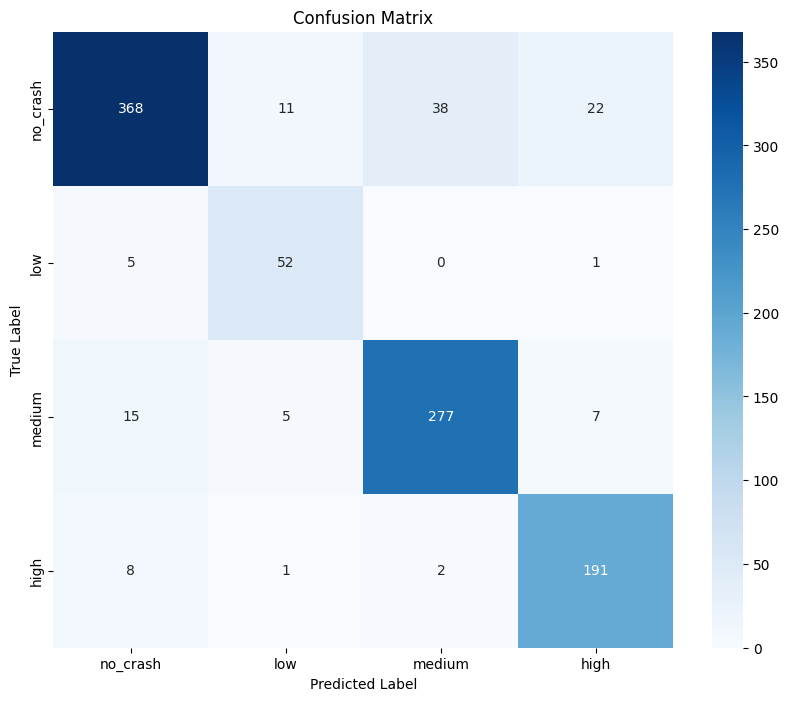

In [2]:
# step_6_evaluate_and_visualize.py
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# --- Configuration ---
class Config:
    OUTPUT_DIR = "/kaggle/working/"
    BATCH_SIZE = 32 # Can use a larger batch size for evaluation
    
config = Config()
# ----------------------------------------------------

# --- Setup Paths and Labels ---
PREPARED_DATA_DIR = f"{config.OUTPUT_DIR}/prepared_dataset/"
MANIFEST_PATH = os.path.join(PREPARED_DATA_DIR, "training_manifest.csv")
# --- IMPORTANT: Updated to use the 'best' model saved by your script ---
MODEL_PATH = f"{config.OUTPUT_DIR}/vit_severity_model_best1.pth"
RESULTS_DIR = f"{config.OUTPUT_DIR}/evaluation_results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

CLASS_NAMES = ['no_crash', 'low', 'medium', 'high']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Using device: {device}")

# --- Re-define Dataset and Model classes (must be identical to training script) ---
class MultimodalDataset(Dataset):
    def __init__(self, manifest_df, transform=None):
        self.manifest_df = manifest_df
        self.transform = transform if transform else transforms.ToTensor()
    def __len__(self): return len(self.manifest_df)
    def __getitem__(self, idx):
        row = self.manifest_df.iloc[idx]
        clip_path = row['clip_path']
        frame_files = sorted(glob.glob(os.path.join(clip_path, "*.jpg")))
        frames = [Image.open(f).convert("RGB") for f in frame_files]
        if not frames: return None, None, None
        video_tensor = torch.stack([self.transform(frame) for frame in frames])
        feature_df = pd.read_csv(row['feature_path'])
        features = feature_df[['max_deceleration', 'max_iou', 'max_direction_change']].values.astype(np.float32)
        feature_tensor = torch.from_numpy(features)
        label = torch.tensor(row['label'], dtype=torch.long)
        return (video_tensor, feature_tensor), label, clip_path

class VisionTransformerAccidentDetector(nn.Module):
    def __init__(self, num_features, num_classes, hidden_size=256, dropout=0.5):
        super(VisionTransformerAccidentDetector, self).__init__()
        self.base_model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=0, global_pool='avg')
        num_video_features = self.base_model.num_features
        self.video_gru = nn.GRU(input_size=num_video_features, hidden_size=hidden_size, batch_first=True)
        self.feature_gru = nn.GRU(input_size=num_features, hidden_size=hidden_size // 4, batch_first=True)
        self.classifier = nn.Sequential(nn.Linear(hidden_size + hidden_size // 4, 512), nn.ReLU(), nn.Dropout(dropout), nn.Linear(512, num_classes))
    def forward(self, video_input, feature_input):
        batch_size, clip_len, C, H, W = video_input.shape
        video_input_reshaped = video_input.view(batch_size * clip_len, C, H, W)
        video_features = self.base_model(video_input_reshaped)
        video_features_seq = video_features.view(batch_size, clip_len, -1)
        _, video_hidden = self.video_gru(video_features_seq)
        _, feature_hidden = self.feature_gru(feature_input)
        video_hidden = video_hidden.squeeze(0); feature_hidden = feature_hidden.squeeze(0)
        fused = torch.cat((video_hidden, feature_hidden), dim=1)
        return self.classifier(fused)

def collate_fn(batch):
    batch = [item for item in batch if item[0] is not None]
    if not batch: return None, None, None
    data_and_labels = [(item[0], item[1]) for item in batch]
    clip_paths = [item[2] for item in batch]
    collated_data, collated_labels = torch.utils.data.dataloader.default_collate(data_and_labels)
    return collated_data, collated_labels, clip_paths

def create_visual_result(clip_path, true_label_str, pred_label_str, output_path):
    frames = []
    frame_files = sorted(glob.glob(os.path.join(clip_path, "*.jpg")))
    is_correct = (true_label_str == pred_label_str)
    text_color = (0, 255, 0) if is_correct else (0, 0, 255)
    for f_path in frame_files:
        frame = cv2.imread(f_path)
        cv2.rectangle(frame, (5, 5), (200, 60), (0,0,0), -1)
        cv2.putText(frame, f"Actual: {true_label_str}", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, text_color, 2)
        cv2.putText(frame, f"Predicted: {pred_label_str}", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, text_color, 2)
        frames.append(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
    if frames:
        frames[0].save(output_path, save_all=True, append_images=frames[1:], duration=100, loop=0)

def main():
    print("--- Step 6: Evaluating and Visualizing Model Results ---")
    manifest_df = pd.read_csv(MANIFEST_PATH)
    _, val_df = train_test_split(manifest_df, test_size=0.2, random_state=42, stratify=manifest_df['label'])
    eval_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    val_dataset = MultimodalDataset(val_df, eval_transform)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)
    
    print(f"Loading model from {MODEL_PATH}")
    model = VisionTransformerAccidentDetector(num_features=3, num_classes=4)
    # The model was saved using nn.DataParallel, so it has a 'module.' prefix in its keys.
    # We need to load it correctly whether we are using DataParallel for evaluation or not.
    state_dict = torch.load(MODEL_PATH)
    model.load_state_dict(state_dict)
        
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs for evaluation!")
        model = nn.DataParallel(model)
    model.to(device)
    model.eval()

    all_preds, all_labels, all_clip_paths = [], [], []
    with torch.no_grad():
        for (video, features), labels, clip_paths in tqdm(val_loader, desc="Evaluating on Validation Set"):
            if video is None: continue
            video, features, labels = video.to(device), features.to(device), labels.to(device)
            outputs = model(video, features)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_clip_paths.extend(clip_paths)

    print("\n--- Classification Report ---")
    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0)
    print(report)
    with open(os.path.join(RESULTS_DIR, "classification_report.txt"), "w") as f: f.write(report)

    print("\n--- Generating Confusion Matrix ---")
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.title('Confusion Matrix')
    plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"))
    print(f"✓ Confusion matrix saved to {RESULTS_DIR}")

    print("\n--- Generating Visual Examples (GIFs) ---")
    results_df = pd.DataFrame({'clip_path': all_clip_paths, 'true_label': all_labels, 'pred_label': all_preds})
    correct_samples = results_df[results_df['true_label'] == results_df['pred_label']].sample(n=min(5, len(results_df[results_df['true_label'] == results_df['pred_label']])))
    incorrect_samples = results_df[results_df['true_label'] != results_df['pred_label']].sample(n=min(5, len(results_df[results_df['true_label'] != results_df['pred_label']])))
    samples_to_visualize = pd.concat([correct_samples, incorrect_samples])
    
    for _, row in tqdm(samples_to_visualize.iterrows(), total=len(samples_to_visualize), desc="Creating GIFs"):
        clip_name = os.path.basename(row['clip_path'])
        true_str, pred_str = CLASS_NAMES[row['true_label']], CLASS_NAMES[row['pred_label']]
        status = "CORRECT" if true_str == pred_str else "INCORRECT"
        gif_filename = f"{status}_{clip_name}.gif"
        output_path = os.path.join(RESULTS_DIR, gif_filename)
        create_visual_result(row['clip_path'], true_str, pred_str, output_path)

    print(f"\n✓ {len(samples_to_visualize)} visual examples saved as GIFs in {RESULTS_DIR}")
    print("\n--- Evaluation Complete ---")

if __name__ == "__main__":
    main()